In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install grad-cam --quiet
# installing the necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import densenet169, DenseNet169_Weights

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
if torch.cuda.is_available():
    gpu_name   = torch.cuda.get_device_name(0)
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"    CUDA Available  : YES")
    print(f"    GPU             : {gpu_name}")
    print(f"    VRAM            : {gpu_mem_gb:.1f} GB")
    print(f"    CUDA Version    : {torch.version.cuda}")
    print(f"    PyTorch         : {torch.__version__}")
    # Quick smoke test
    _t = torch.randn(512, 512, device='cuda')
    _  = _t @ _t
    del _t
    torch.cuda.empty_cache()
    print(f"   GPU Tensor Test : PASSED")
else:
    print(" No GPU detected!")
    print("      Go to:  Runtime → Change runtime type → T4 GPU")

print("=" * 55)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Training device: {device}")

    CUDA Available  : YES
    GPU             : Tesla T4
    VRAM            : 15.6 GB
    CUDA Version    : 12.8
    PyTorch         : 2.10.0+cu128
   GPU Tensor Test : PASSED
  Training device: cuda


In [ ]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [ ]:
class Config:

    DATA_DIR     = "/content/drive/MyDrive/Colab Notebooks/Alzheimer/Dataset"
    OUTPUT_DIR   = "/content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs"
    MODEL_DIR    = "/content/drive/MyDrive/Colab Notebooks/Alzheimer/Models"

    # number of classes
    CLASSES      = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
    NUM_CLASSES  = 4
    SAMPLES_PER_CLASS = 4000


    MODEL_NAME   = 'densenet169'
    IMG_SIZE     = 224
    DROPOUT      = 0.4

    # training configurations
    BATCH_SIZE   = 32
    NUM_EPOCHS   = 40
    LR           = 1e-4
    LR_MIN       = 1e-6
    WEIGHT_DECAY = 1e-4
    PATIENCE     = 5


    TRAIN_RATIO  = 0.70
    VAL_RATIO    = 0.15
    TEST_RATIO   = 0.15

cfg = Config()

# Create output dirs
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
os.makedirs(cfg.MODEL_DIR,  exist_ok=True)
print("Config loaded. Directories created.")

Config loaded. Directories created.


DATASET EXPLORATION
  NonDemented            : 12800 images available
  VeryMildDemented       : 11215 images available
  MildDemented           : 10000 images available
  ModerateDemented       : 10000 images available

  Sampling 4000 per class
  Total training pool : 16000 images


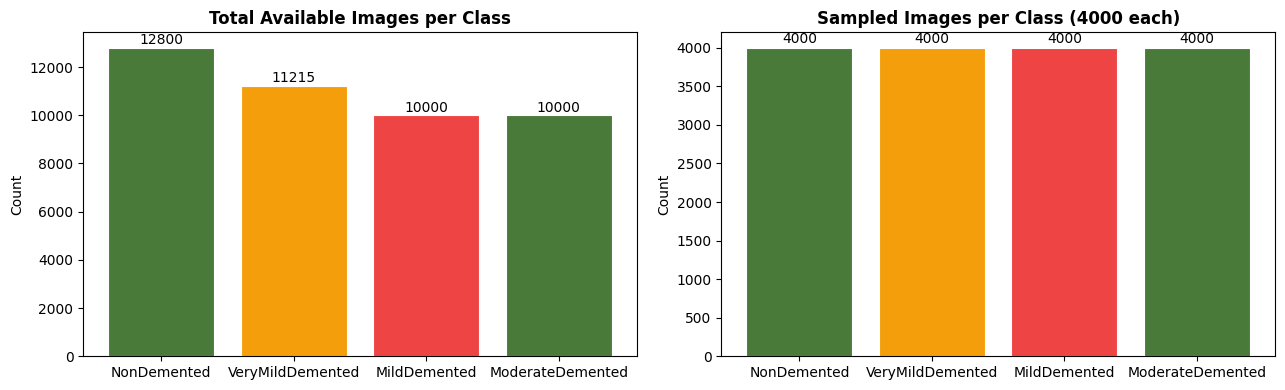

Saved: class_distribution.png


In [ ]:
print("=" * 55)
print("DATASET EXPLORATION")
print("=" * 55)

total_available = {}
for cls in cfg.CLASSES:
    cls_path = os.path.join(cfg.DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    total_available[cls] = len(files)
    print(f"  {cls:<22} : {len(files):>5} images available")

print(f"\n  Sampling {cfg.SAMPLES_PER_CLASS} per class")
print(f"  Total training pool : {cfg.SAMPLES_PER_CLASS * cfg.NUM_CLASSES} images")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#4a7a3a', '#f59e0b', '#ef4444']

# Available
axes[0].bar(total_available.keys(), total_available.values(),
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Total Available Images per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, total_available.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', va='bottom', fontsize=10)

# Sampled
sampled = {cls: cfg.SAMPLES_PER_CLASS for cls in cfg.CLASSES}
axes[1].bar(sampled.keys(), sampled.values(),
            color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title(f'Sampled Images per Class ({cfg.SAMPLES_PER_CLASS} each)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(cfg.SAMPLES_PER_CLASS), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

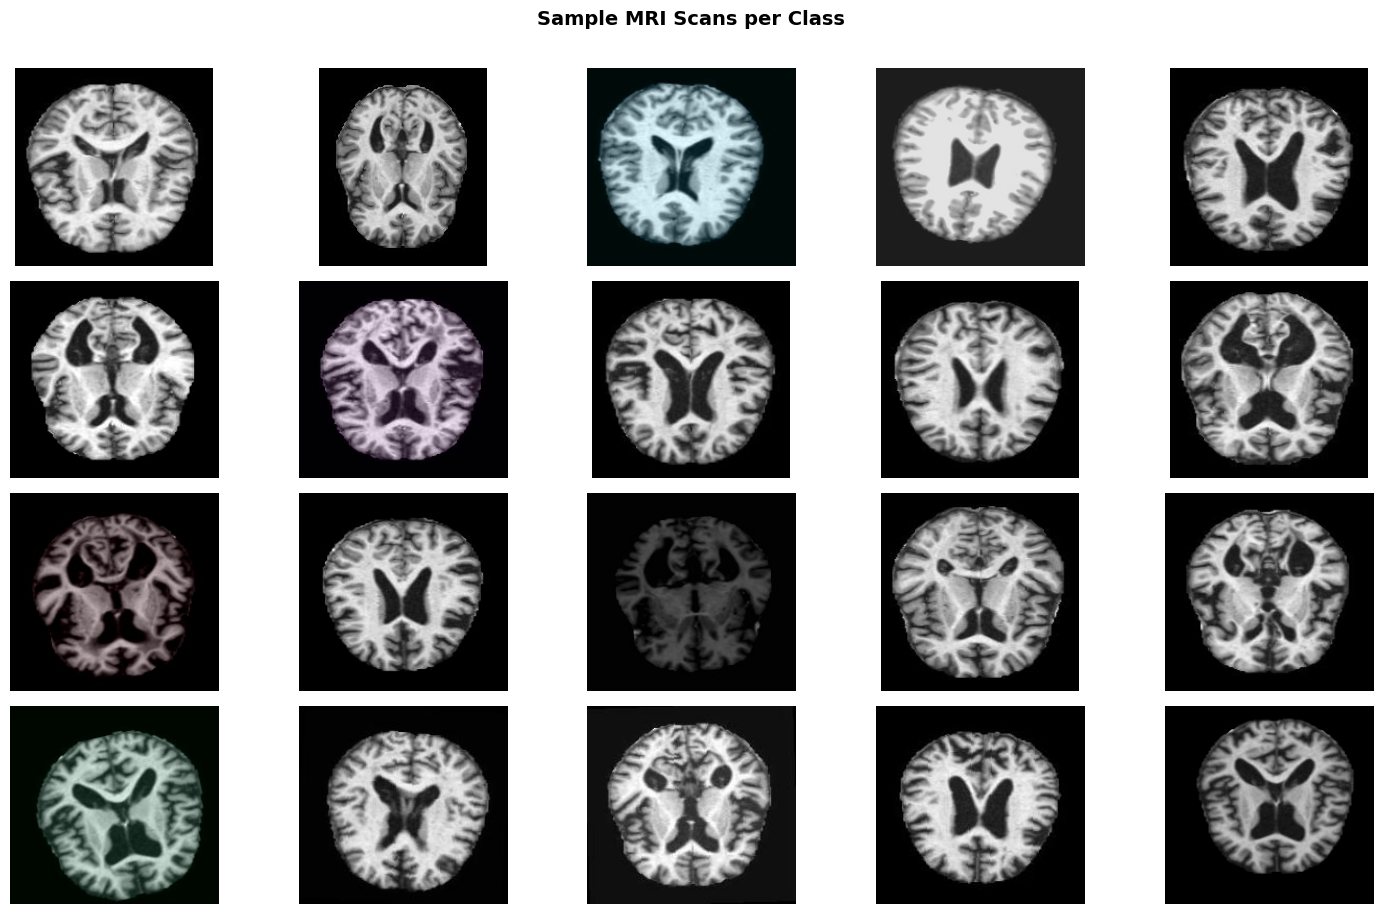

Saved: sample_mri_scans.png


In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(15, 9))
fig.suptitle('Sample MRI Scans per Class', fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(cfg.CLASSES):
    cls_path = os.path.join(cfg.DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    samples = random.sample(files, 5)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_path, fname)).convert('RGB')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0,
                                      labelpad=80, va='center')

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/sample_mri_scans.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_mri_scans.png")


In [ ]:
# A custom PyTorch Dataset class for loading Alzheimer's disease images
class AlzheimerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    # To return the total number of samples in the dataset
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [ ]:
# Create and return training and validation/test data transformation pipelines.
def get_transforms():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

     # data augmentation to improve model generalization and reduce overfitting
    train_transform = transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE + 16, cfg.IMG_SIZE + 16)),
        transforms.CenterCrop(cfg.IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.97, 1.03)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    # validation and test data transformation pipeline
    val_test_transform = transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return train_transform, val_test_transform

In [ ]:
def build_splits():
    all_paths, all_labels = [], []

    for label_idx, cls in enumerate(cfg.CLASSES):
        cls_path = os.path.join(cfg.DATA_DIR, cls)
        files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Sample exactly SAMPLES_PER_CLASS
        sampled = random.sample(files, min(cfg.SAMPLES_PER_CLASS, len(files)))
        for fname in sampled:
            all_paths.append(os.path.join(cls_path, fname))
            all_labels.append(label_idx)

    # Shuffle together
    combined = list(zip(all_paths, all_labels))
    random.shuffle(combined)
    all_paths, all_labels = zip(*combined)
    all_paths  = list(all_paths)
    all_labels = list(all_labels)

    n = len(all_paths)
    n_train = int(n * cfg.TRAIN_RATIO)
    n_val   = int(n * cfg.VAL_RATIO)

    train_paths  = all_paths[:n_train]
    train_labels = all_labels[:n_train]
    val_paths    = all_paths[n_train:n_train + n_val]
    val_labels   = all_labels[n_train:n_train + n_val]
    test_paths   = all_paths[n_train + n_val:]
    test_labels  = all_labels[n_train + n_val:]

    print("=" * 45)
    print("DATASET SPLITS")
    print("=" * 45)
    print(f"  Train : {len(train_paths):>5} images")
    print(f"  Val   : {len(val_paths):>5} images")
    print(f"  Test  : {len(test_paths):>5} images")
    print(f"  Total : {n:>5} images")

    return (train_paths, train_labels,
            val_paths, val_labels,
            test_paths, test_labels)


train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = build_splits()
train_tf, val_test_tf = get_transforms()

train_ds = AlzheimerDataset(train_paths, train_labels, train_tf)
val_ds   = AlzheimerDataset(val_paths,   val_labels,   val_test_tf)
test_ds  = AlzheimerDataset(test_paths,  test_labels,  val_test_tf)

# Weighted sampler so each class is equally represented per batch
class_counts  = Counter(train_labels)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_labels), replacement=True)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"\n  Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")


DATASET SPLITS
  Train : 11200 images
  Val   :  2400 images
  Test  :  2400 images
  Total : 16000 images

  Batches — Train: 350, Val: 75, Test: 75


In [ ]:
class AlzheimerClassifier(nn.Module):
    def __init__(self, model_name='densenet169',
                 num_classes=3, dropout=0.4):
        super().__init__()
        self.model_name = model_name

        if model_name == 'densenet169':
            self.backbone = densenet169(weights=DenseNet169_Weights.IMAGENET1K_V1)
            in_features   = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Identity()

        else:
            raise ValueError(f"Unsupported model: {model_name}")

        # Custom classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout * 0.75),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("Backbone frozen.")

    def unfreeze_backbone(self):
        """Selective unfreeze — keeps early low-level layers frozen."""
        for param in self.backbone.parameters():
            param.requires_grad = True

        freeze_layers = ['features.denseblock1', 'features.denseblock2',
                 'features.conv0', 'features.norm0']

        for name, param in self.backbone.named_parameters():
            if any(l in name for l in freeze_layers):
                param.requires_grad = False

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Selective unfreeze done. Trainable params: {trainable:,}")

In [ ]:
class EarlyStopping:
    def __init__(self, patience=8, delta=1e-4):
        self.patience   = patience
        self.delta      = delta
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0


# Train one epoch
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds    = []
    all_labels   = []

    progress_bar = tqdm(dataloader, desc='  Training  ', leave=True,
                        bar_format='{desc}: {percentage:3.0f}%|{bar:30}| '
                                   '{n_fmt}/{total_fmt} '
                                   '[{elapsed}<{remaining}] {postfix}')

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


#  Validate one epoch
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds    = []
    all_labels   = []
    all_probs    = []

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='  Validating', leave=True,
                            bar_format='{desc}: {percentage:3.0f}%|{bar:30}| '
                                       '{n_fmt}/{total_fmt} '
                                       '[{elapsed}<{remaining}] {postfix}')

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            probs  = F.softmax(outputs, dim=1)
            preds  = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)


print("Training utilities loaded ✓")

Training utilities loaded ✓


In [ ]:
# Full Training Loop

import torch.optim as optim

def train_model(model_name='densenet169'):

    print("\n" + "=" * 60)
    print(f"  TRAINING: {model_name.upper()}")
    print("=" * 60)

    model     = AlzheimerClassifier(model_name, cfg.NUM_CLASSES, cfg.DROPOUT).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [],
        'lr':         []
    }

    best_val_loss   = float('inf')
    patience_counter = 0
    best_model_path  = f"{cfg.MODEL_DIR}/{model_name}_best.pt"
    total_start      = time.time()

    #  Phase 1: Warmup head only (5 epochs)
    print("\n  Phase 1 — Warmup: training classifier head only (5 epochs)")
    print("  Backbone frozen — only the custom head is updated")
    print("-" * 60)

    model.freeze_backbone()
    optimizer_p1 = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
    )

    for epoch in range(1, 6):
        print(f"\n  Warmup Epoch {epoch}/5")
        print("-" * 60)
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer_p1, device)
        val_loss, val_acc, *_ = validate_epoch(
            model, val_loader, criterion, device)
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    #  Phase 2: Fine-tune selective layers
    print("\n\n  Phase 2 — Fine-tuning with cosine LR and early stopping")
    print("  Deeper backbone layers unfrozen selectively")
    print("-" * 60)

    model.unfreeze_backbone()
    optimizer_p2 = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.LR / 5, weight_decay=cfg.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_p2, T_max=cfg.NUM_EPOCHS, eta_min=cfg.LR_MIN
    )
    early_stop = EarlyStopping(patience=cfg.PATIENCE)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        epoch_start = time.time()

        print(f"\n  Epoch {epoch}/{cfg.NUM_EPOCHS}")
        print("-" * 60)

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer_p2, device)

        # Validate
        val_loss, val_acc, *_ = validate_epoch(
            model, val_loader, criterion, device)

        scheduler.step()
        epoch_time = time.time() - epoch_start
        current_lr = scheduler.get_last_lr()[0]
        history['lr'].append(current_lr)

        # Estimate remaining time
        elapsed   = time.time() - total_start
        avg_ep    = elapsed / epoch
        remaining = avg_ep * (cfg.NUM_EPOCHS - epoch)
        eta_str   = f"{int(remaining//60)}m {int(remaining%60)}s"

        # Print epoch summary
        print(f"\n  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
        print(f"  LR: {current_lr:.2e} | Epoch time: {epoch_time:.1f}s | ETA: {eta_str}")

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch':      epoch,
                'model_name': model_name,
                'state_dict': model.state_dict(),
                'val_acc':    val_acc,
                'classes':    cfg.CLASSES
            }, best_model_path)
            print(f"  Best model saved → {best_model_path}")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{cfg.PATIENCE}")

        # Early stopping check
        early_stop(val_loss)
        if early_stop.stop:
            print(f"\n  Early stopping triggered at epoch {epoch}")
            break

    #  Final summary
    total_time = time.time() - total_start
    print("\n" + "=" * 60)
    print("  TRAINING COMPLETE")
    print("=" * 60)
    print(f"  Model        : {model_name.upper()}")
    print(f"  Best Val Loss: {best_val_loss:.4f}")
    print(f"  Total time   : {int(total_time//60)}m {int(total_time%60)}s")
    print(f"  Saved to     : {best_model_path}")
    print("=" * 60)

    import json
    history_path = f"{cfg.MODEL_DIR}/{cfg.MODEL_NAME}_history.json"
    with open(history_path, 'w') as f:
        json.dump(history, f)
    print(f"  History saved → {history_path}")

    return model, history, best_model_path


#  Run
model, history, best_model_path = train_model(cfg.MODEL_NAME)



  TRAINING: DENSENET169

  Phase 1 — Warmup: training classifier head only (5 epochs)
  Backbone frozen — only the custom head is updated
------------------------------------------------------------
Backbone frozen.

  Warmup Epoch 1/5
------------------------------------------------------------


  Validating: 100%|██████████████████████████████| 75/75 [05:49<00:00] , loss=1.0966


  Train Loss: 1.2271 | Train Acc: 0.4610
  Val   Loss: 1.0606 | Val   Acc: 0.5913

  Warmup Epoch 2/5
------------------------------------------------------------


  Validating: 100%|██████████████████████████████| 75/75 [00:14<00:00] , loss=1.0755


  Train Loss: 1.1053 | Train Acc: 0.5398
  Val   Loss: 1.0275 | Val   Acc: 0.5996

  Warmup Epoch 3/5
------------------------------------------------------------


...


  Train Loss: 0.3613 | Train Acc: 0.9976
  Val   Loss: 0.3874 | Val   Acc: 0.9846
  LR: 1.12e-06 | Epoch time: 127.2s | ETA: 6m 30s
  No improvement. Patience: 3/5

  Epoch 39/40
------------------------------------------------------------


  Validating: 100%|██████████████████████████████| 75/75 [00:14<00:00] , loss=0.3496



  Train Loss: 0.3602 | Train Acc: 0.9976
  Val   Loss: 0.3860 | Val   Acc: 0.9846
  LR: 1.03e-06 | Epoch time: 127.6s | ETA: 3m 13s
  Best model saved → /content/drive/MyDrive/Colab Notebooks/Alzheimer/Models/densenet169_best.pt

  Epoch 40/40
------------------------------------------------------------


  Validating: 100%|██████████████████████████████| 75/75 [00:14<00:00] , loss=0.3495


  Train Loss: 0.3606 | Train Acc: 0.9975
  Val   Loss: 0.3889 | Val   Acc: 0.9833
  LR: 1.00e-06 | Epoch time: 127.9s | ETA: 0m 0s
  No improvement. Patience: 1/5

  TRAINING COMPLETE
  Model        : DENSENET169
  Best Val Loss: 0.3860
  Total time   : 127m 55s
  Saved to     : /content/drive/MyDrive/Colab Notebooks/Alzheimer/Models/densenet169_best.pt
  History saved → /content/drive/MyDrive/Colab Notebooks/Alzheimer/Models/densenet169_history.json


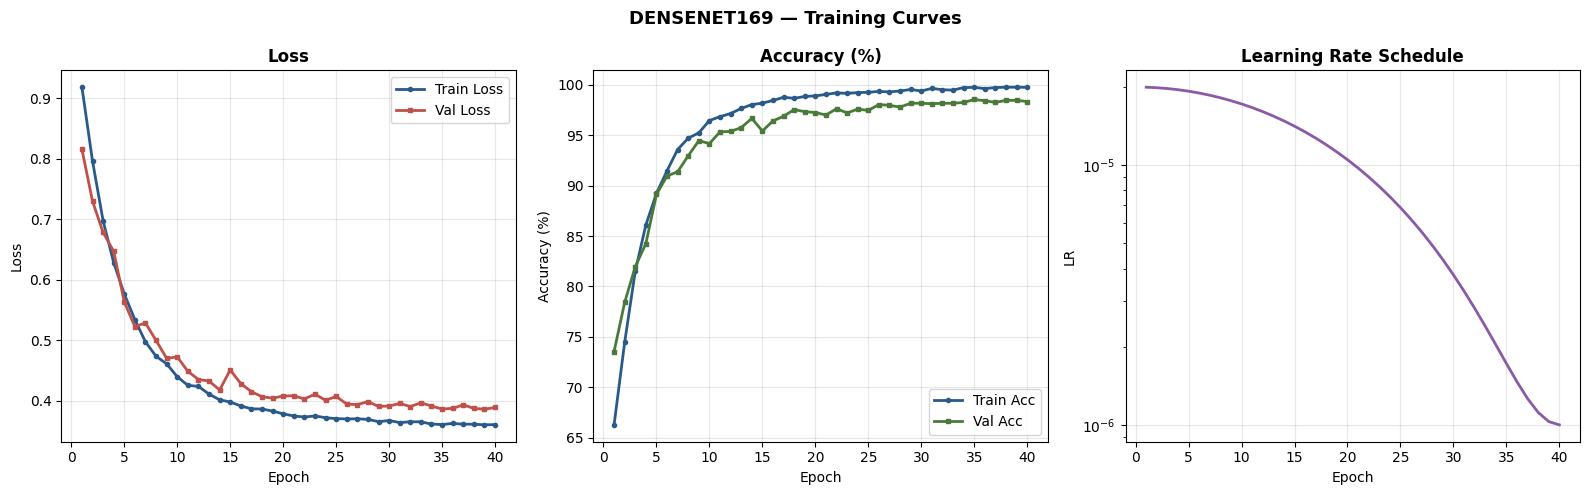

Saved: densenet169_training_curves.png


In [ ]:
def plot_training_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{model_name.upper()} — Training Curves', fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'o-', color='#2a5a8a', label='Train Loss', linewidth=2, markersize=3)
    axes[0].plot(epochs, history['val_loss'],   's-', color='#c0504a', label='Val Loss',   linewidth=2, markersize=3)
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'o-', color='#2a5a8a', label='Train Acc', linewidth=2, markersize=3)
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   's-', color='#4a7a3a', label='Val Acc',   linewidth=2, markersize=3)
    axes[1].set_title('Accuracy (%)', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # Learning Rate
    axes[2].plot(epochs, history['lr'], '-', color='#8a5aa8', linewidth=2)
    axes[2].set_title('Learning Rate Schedule', fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
    axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{cfg.OUTPUT_DIR}/{model_name}_training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {model_name}_training_curves.png")

plot_training_curves(history, cfg.MODEL_NAME)

In [ ]:
import torch

best_model_path = f"{cfg.MODEL_DIR}/{cfg.MODEL_NAME}_best.pt"
checkpoint      = torch.load(best_model_path, map_location=device)

print("=" * 50)
print("  MODEL LOADED FROM CHECKPOINT")
print("=" * 50)
print(f"  Model      : {checkpoint['model_name']}")
print(f"  Saved epoch: {checkpoint['epoch']}")
print(f"  Val Acc    : {checkpoint['val_acc']*100:.2f}%")
print(f"  Classes    : {checkpoint['classes']}")
print("=" * 50)

  MODEL LOADED FROM CHECKPOINT
  Model      : densenet169
  Saved epoch: 18
  Val Acc    : 99.72%
  Classes    : ['NonDemented', 'MildDemented', 'ModerateDemented']


In [ ]:
def load_best_model(model_path, model_name):
    model = AlzheimerClassifier(model_name, cfg.NUM_CLASSES, cfg.DROPOUT).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']} "
          f"(val_acc = {checkpoint['val_acc']:.4f})")
    return model

criterion = nn.CrossEntropyLoss()
best_model = load_best_model(best_model_path, cfg.MODEL_NAME)

_, test_acc, test_preds, test_labels_arr, test_probs = validate_epoch(
    best_model, test_loader, criterion, device
)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

Loaded best model from epoch 39 (val_acc = 0.9846)


  Validating: 100%|██████████████████████████████| 75/75 [05:14<00:00] , loss=0.0770


Test Accuracy: 98.29%


In [ ]:
print("\n" + "=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
report = classification_report(
    test_labels_arr, test_preds,
    target_names=cfg.CLASSES, digits=4
)
print(report)

# Save as CSV for report
report_dict = classification_report(
    test_labels_arr, test_preds,
    target_names=cfg.CLASSES, output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(f"{cfg.OUTPUT_DIR}/{cfg.MODEL_NAME}_classification_report.csv")
print("Saved: classification_report.csv")


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     NonDemented     0.9700    0.9684    0.9692       601
VeryMildDemented     0.9700    0.9652    0.9676       603
    MildDemented     0.9917    0.9983    0.9950       601
ModerateDemented     1.0000    1.0000    1.0000       595

        accuracy                         0.9829      2400
       macro avg     0.9829    0.9830    0.9829      2400
    weighted avg     0.9829    0.9829    0.9829      2400

Saved: classification_report.csv


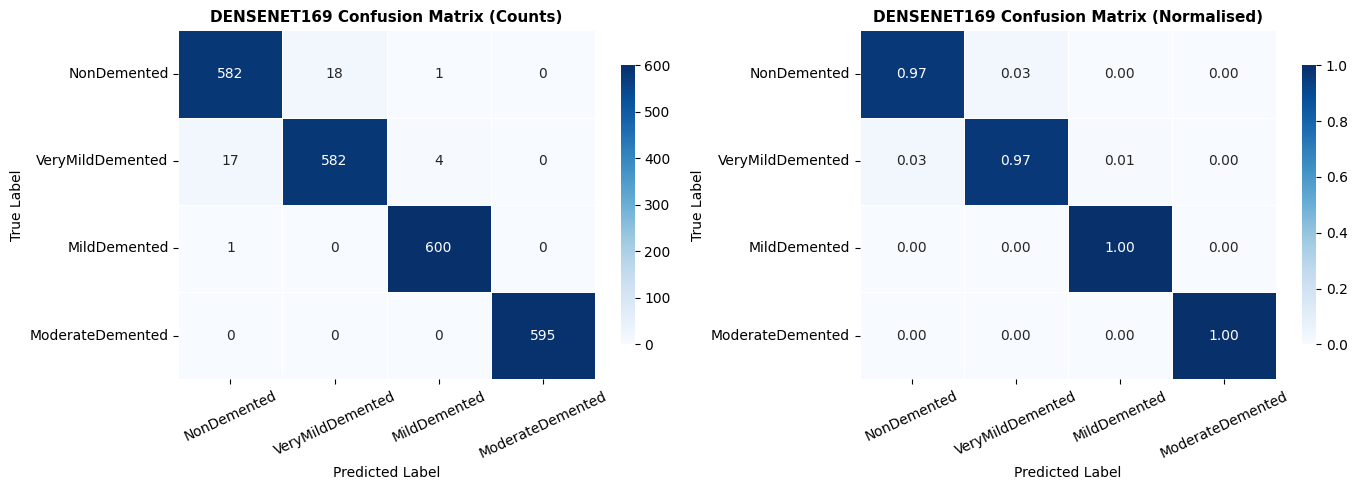

Saved: confusion_matrix.png

Per-Class Statistics:
Class                      TP     FP     FN     TN
---------------------------------------------
  NonDemented             582     18     19   1781
  VeryMildDemented        582     18     21   1779
  MildDemented            600      5      1   1794
  ModerateDemented        595      0      0   1805


In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, model_name, normalise=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalise:
        cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt, title_tag = '.2f', '(Normalised)'
    else:
        cm_plot = cm
        fmt, title_tag = 'd', '(Counts)'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (data, f, tag) in zip(axes, [
        (cm, 'd', '(Counts)'),
        (cm.astype(float) / cm.sum(axis=1, keepdims=True), '.2f', '(Normalised)')
    ]):
        sns.heatmap(data, annot=True, fmt=f, cmap='Blues',
                    xticklabels=classes, yticklabels=classes,
                    ax=ax, linewidths=0.5, linecolor='white',
                    cbar_kws={'shrink': 0.8})
        ax.set_title(f'{model_name.upper()} Confusion Matrix {tag}',
                     fontweight='bold', fontsize=11)
        ax.set_ylabel('True Label', fontsize=10)
        ax.set_xlabel('Predicted Label', fontsize=10)
        ax.tick_params(axis='x', rotation=25)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(f"{cfg.OUTPUT_DIR}/{model_name}_confusion_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix.png")

    # Print per-class stats
    print("\nPer-Class Statistics:")
    print(f"{'Class':<22} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>6}")
    print("-" * 45)
    for i, cls in enumerate(classes):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - TP - FP - FN
        print(f"  {cls:<20} {TP:>6} {FP:>6} {FN:>6} {TN:>6}")

plot_confusion_matrix(test_labels_arr, test_preds, cfg.CLASSES, cfg.MODEL_NAME)

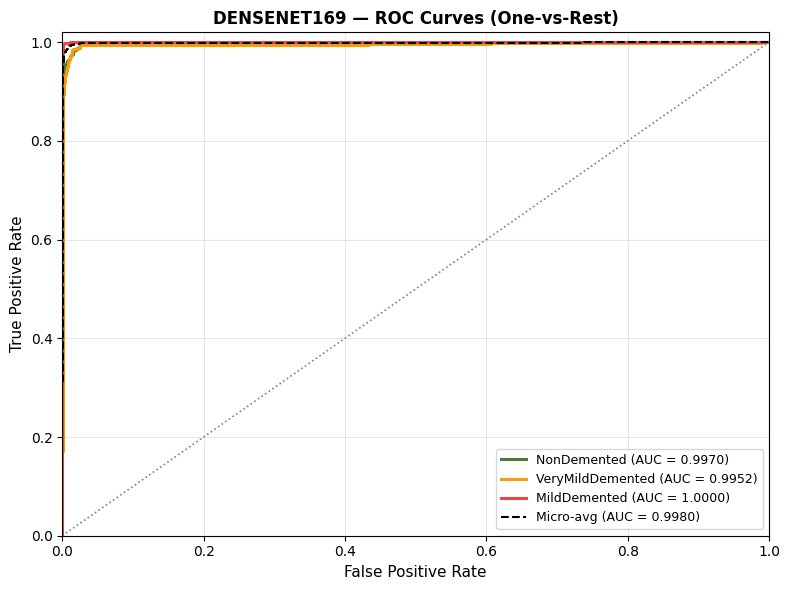

Saved: roc_curves.png

AUC Scores:
  NonDemented           : 0.9970
  VeryMildDemented      : 0.9952
  MildDemented          : 1.0000
  Micro-average         : 0.9980


In [ ]:
# Plotting the ROC Curves
def plot_roc_curves(y_true, y_probs, classes, model_name):
    y_bin = label_binarize(y_true, classes=list(range(len(classes))))

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#4a7a3a', '#f59e0b', '#ef4444']

    auc_scores = {}
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores[cls] = roc_auc
        ax.plot(fpr, tpr, color=color, lw=2.2,
                label=f'{cls} (AUC = {roc_auc:.4f})')

    # Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), y_probs.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    ax.plot(fpr_micro, tpr_micro, 'k--', lw=1.5,
            label=f'Micro-avg (AUC = {auc_micro:.4f})')

    ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1.2)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{model_name.upper()} — ROC Curves (One-vs-Rest)', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{cfg.OUTPUT_DIR}/{model_name}_roc_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: roc_curves.png")

    print("\nAUC Scores:")
    for cls, score in auc_scores.items():
        print(f"  {cls:<22}: {score:.4f}")
    print(f"  {'Micro-average':<22}: {auc_micro:.4f}")
    return auc_scores

auc_scores = plot_roc_curves(test_labels_arr, test_probs, cfg.CLASSES, cfg.MODEL_NAME)

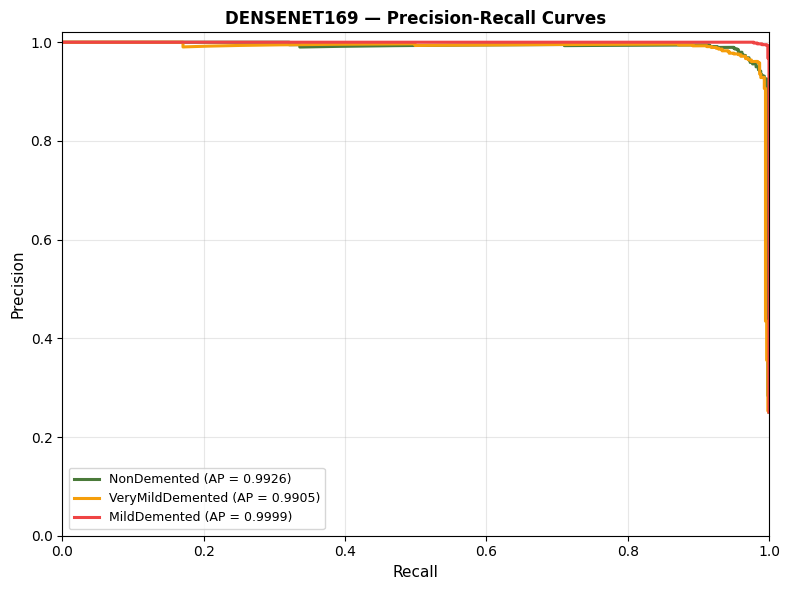

Saved: pr_curves.png


In [ ]:
def plot_precision_recall(y_true, y_probs, classes, model_name):
    y_bin  = label_binarize(y_true, classes=list(range(len(classes))))
    colors = ['#4a7a3a', '#f59e0b', '#ef4444']

    fig, ax = plt.subplots(figsize=(8, 6))

    for i, (cls, color) in enumerate(zip(classes, colors)):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_probs[:, i])
        ap = average_precision_score(y_bin[:, i], y_probs[:, i])
        ax.plot(recall, precision, color=color, lw=2.2,
                label=f'{cls} (AP = {ap:.4f})')

    ax.set_xlabel('Recall',    fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'{model_name.upper()} — Precision-Recall Curves', fontweight='bold', fontsize=12)
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

    plt.tight_layout()
    plt.savefig(f"{cfg.OUTPUT_DIR}/{model_name}_pr_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: pr_curves.png")

plot_precision_recall(test_labels_arr, test_probs, cfg.CLASSES, cfg.MODEL_NAME)

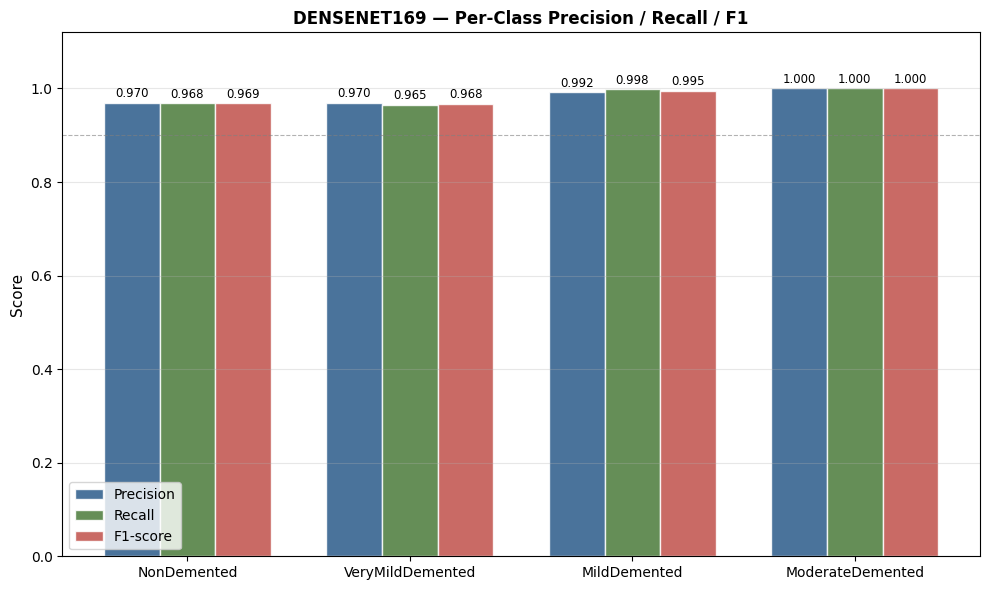

Saved: per_class_metrics.png


In [ ]:
# Plotting the Precision, Recall and F1-Score for each class
def plot_per_class_metrics(y_true, y_pred, classes, model_name):
    report_dict = classification_report(
        y_true, y_pred, target_names=classes, output_dict=True
    )
    metrics = ['precision', 'recall', 'f1-score']
    x = np.arange(len(classes))
    width = 0.25
    colors = ['#2a5a8a', '#4a7a3a', '#c0504a']

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (metric, color) in enumerate(zip(metrics, colors)):
        vals = [report_dict[cls][metric] for cls in classes]
        bars = ax.bar(x + i * width, vals, width, label=metric.capitalize(),
                      color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels(classes, fontsize=10)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim([0, 1.12])
    ax.set_title(f'{model_name.upper()} — Per-Class Precision / Recall / F1',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

    plt.tight_layout()
    plt.savefig(f"{cfg.OUTPUT_DIR}/{model_name}_per_class_metrics.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: per_class_metrics.png")

plot_per_class_metrics(test_labels_arr, test_preds, cfg.CLASSES, cfg.MODEL_NAME)

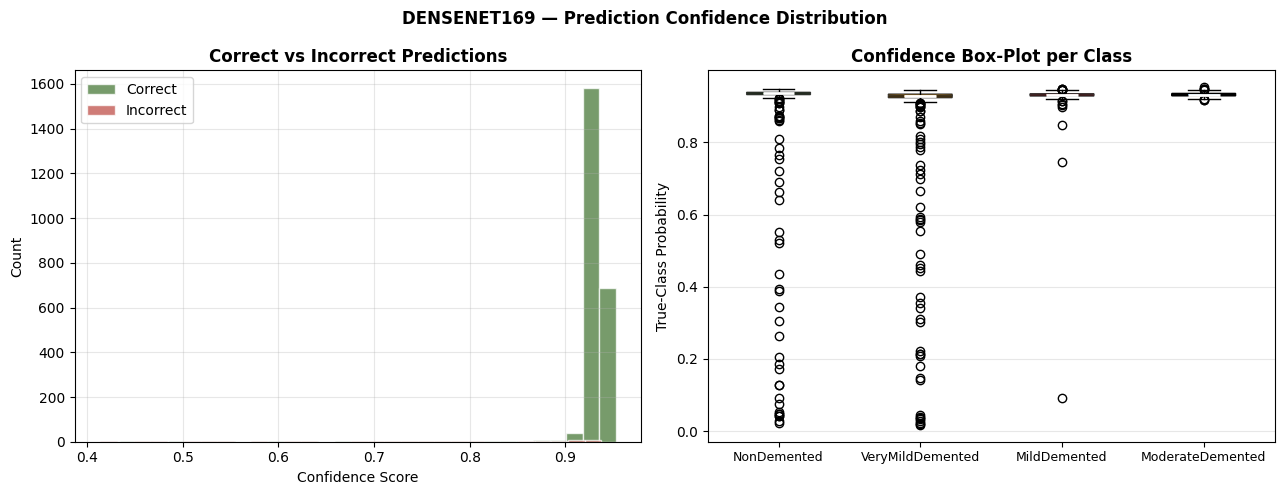

Saved: confidence_distribution.png


In [ ]:
def plot_confidence_distribution(y_true, y_probs, y_preds, classes, model_name):
    correct_conf   = []
    incorrect_conf = []

    for true, pred, probs in zip(y_true, y_preds, y_probs):
        conf = probs[pred]
        if true == pred:
            correct_conf.append(conf)
        else:
            incorrect_conf.append(conf)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{model_name.upper()} — Prediction Confidence Distribution',
                 fontweight='bold', fontsize=12)

    # Overall correct vs incorrect
    axes[0].hist(correct_conf,   bins=30, color='#4a7a3a', alpha=0.75, label='Correct', edgecolor='white')
    axes[0].hist(incorrect_conf, bins=30, color='#c0504a', alpha=0.75, label='Incorrect', edgecolor='white')
    axes[0].set_xlabel('Confidence Score', fontsize=10)
    axes[0].set_ylabel('Count', fontsize=10)
    axes[0].set_title('Correct vs Incorrect Predictions', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Per-class predicted probability box plots
    class_probs = {cls: [] for cls in classes}
    for true, probs in zip(y_true, y_probs):
        class_probs[classes[true]].append(probs[true])

    data   = [class_probs[cls] for cls in classes]
    colors = ['#4a7a3a', '#f59e0b', '#ef4444']
    bp = axes[1].boxplot(data, patch_artist=True, notch=True,
                          medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    axes[1].set_xticklabels(classes, fontsize=9)
    axes[1].set_ylabel('True-Class Probability', fontsize=10)
    axes[1].set_title('Confidence Box-Plot per Class', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{cfg.OUTPUT_DIR}/{model_name}_confidence_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confidence_distribution.png")

plot_confidence_distribution(test_labels_arr, test_probs, test_preds, cfg.CLASSES, cfg.MODEL_NAME)

In [ ]:
def print_summary_metrics(y_true, y_pred, y_probs, classes, model_name):
    report_dict = classification_report(
        y_true, y_pred, target_names=classes, output_dict=True
    )
    y_bin = label_binarize(y_true, classes=list(range(len(classes))))
    macro_auc = roc_auc_score(y_bin, y_probs, average='macro')

    print("\n" + "=" * 58)
    print(f" SUMMARY — {model_name.upper()}")
    print("=" * 58)
    print(f"  {'Metric':<30} {'Value':>10}")
    print("-" * 58)
    print(f"  {'Test Accuracy':<30} {report_dict['accuracy']:>10.4f}")
    print(f"  {'Macro Precision':<30} {report_dict['macro avg']['precision']:>10.4f}")
    print(f"  {'Macro Recall':<30} {report_dict['macro avg']['recall']:>10.4f}")
    print(f"  {'Macro F1-Score':<30} {report_dict['macro avg']['f1-score']:>10.4f}")
    print(f"  {'Weighted F1-Score':<30} {report_dict['weighted avg']['f1-score']:>10.4f}")
    print(f"  {'Macro AUC (OvR)':<30} {macro_auc:>10.4f}")
    print("=" * 58)

print_summary_metrics(test_labels_arr, test_preds, test_probs, cfg.CLASSES, cfg.MODEL_NAME)


 SUMMARY — DENSENET169
  Metric                              Value
----------------------------------------------------------
  Test Accuracy                      0.9829
  Macro Precision                    0.9829
  Macro Recall                       0.9830
  Macro F1-Score                     0.9829
  Weighted F1-Score                  0.9829
  Macro AUC (OvR)                    0.9980



Generating Grad-CAM examples...
Saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs/gradcam_NonDemented_1.png


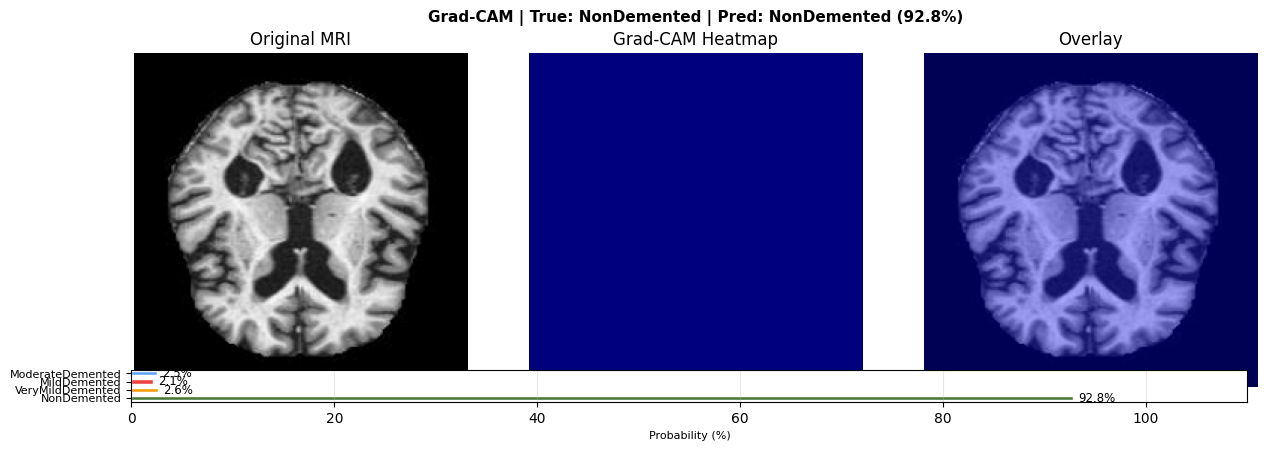

Saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs/gradcam_NonDemented_2.png


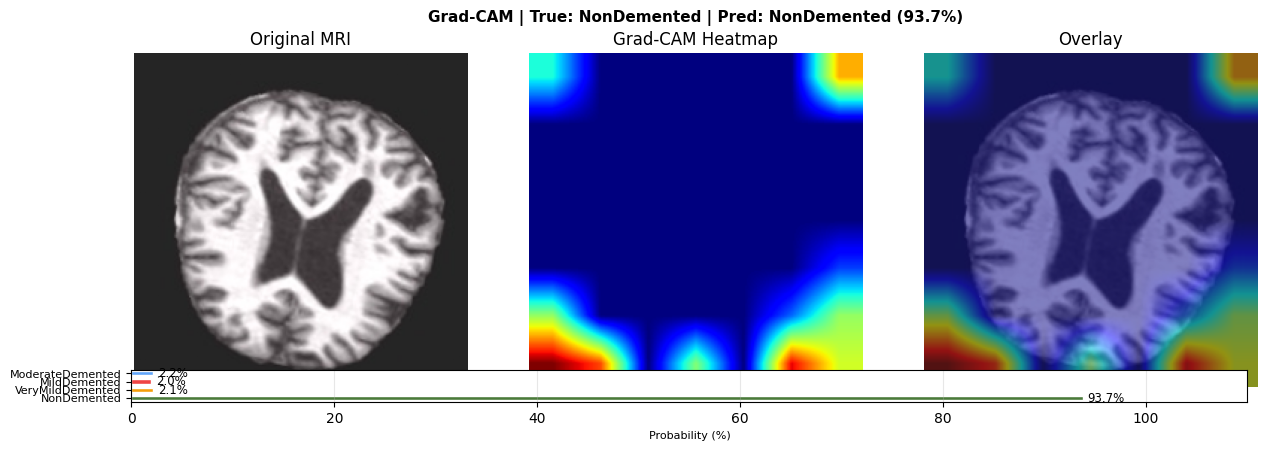

Saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs/gradcam_VeryMildDemented_1.png


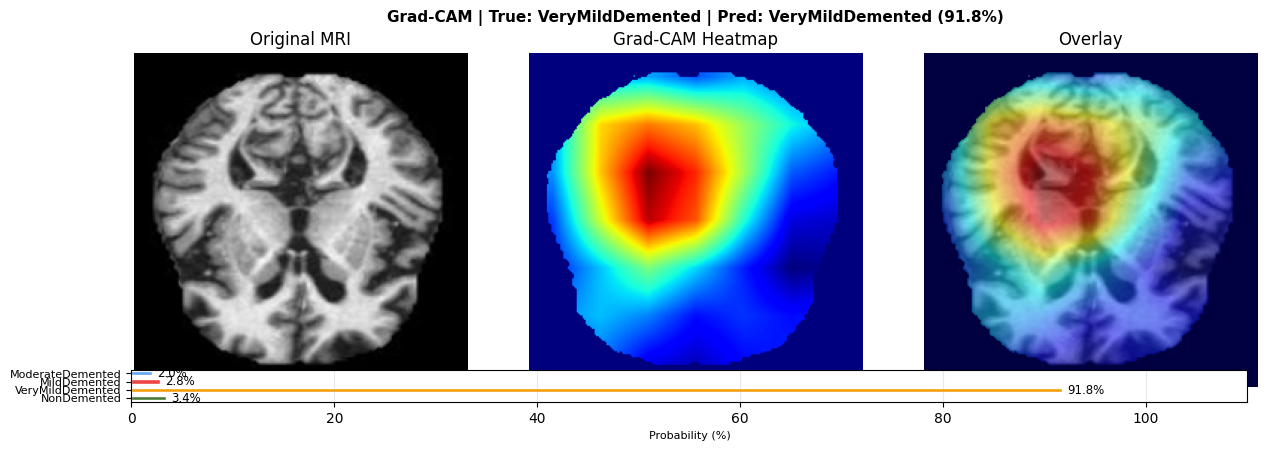

Saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs/gradcam_VeryMildDemented_2.png


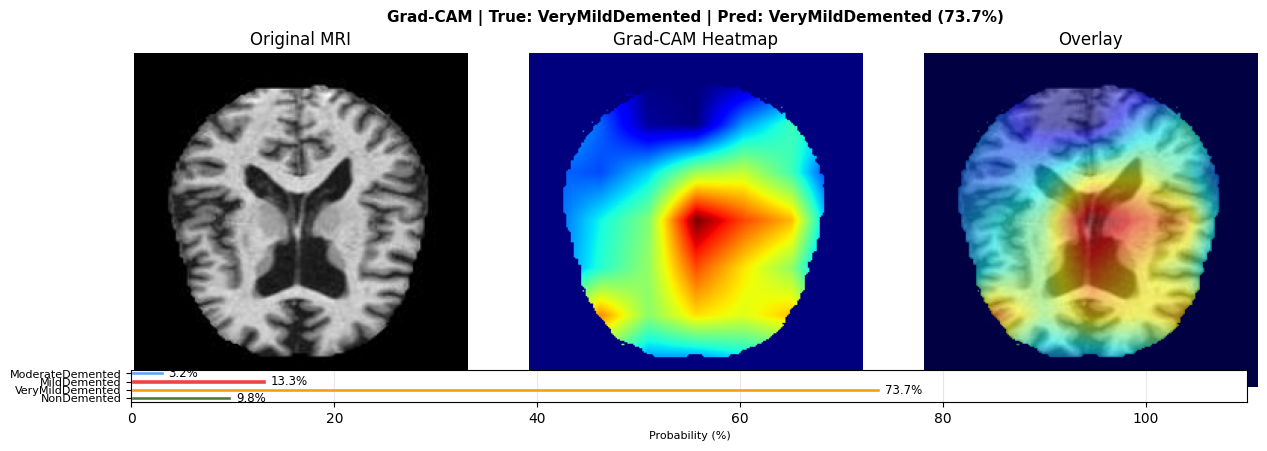

Saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs/gradcam_MildDemented_1.png


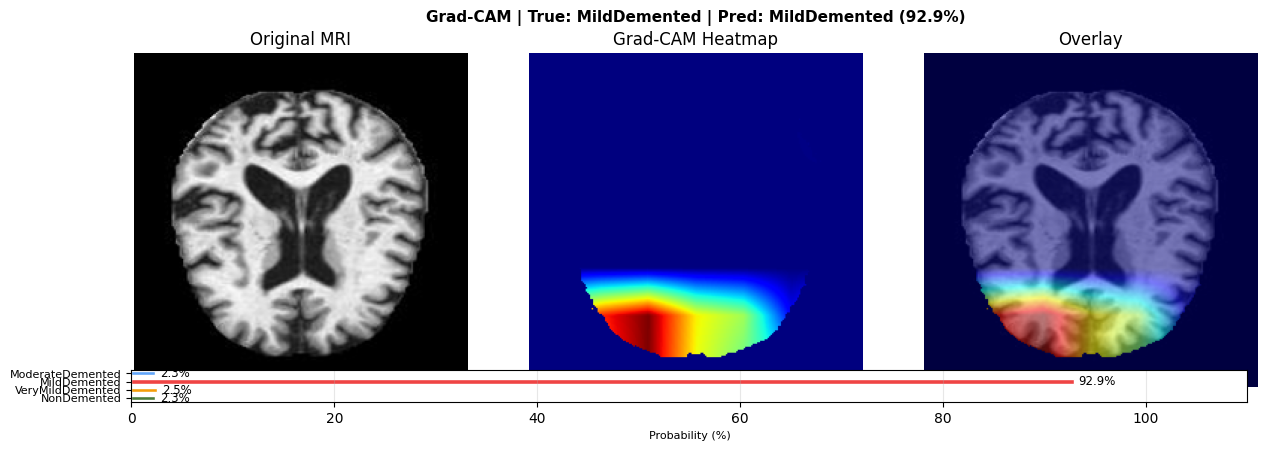

Saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs/gradcam_MildDemented_2.png


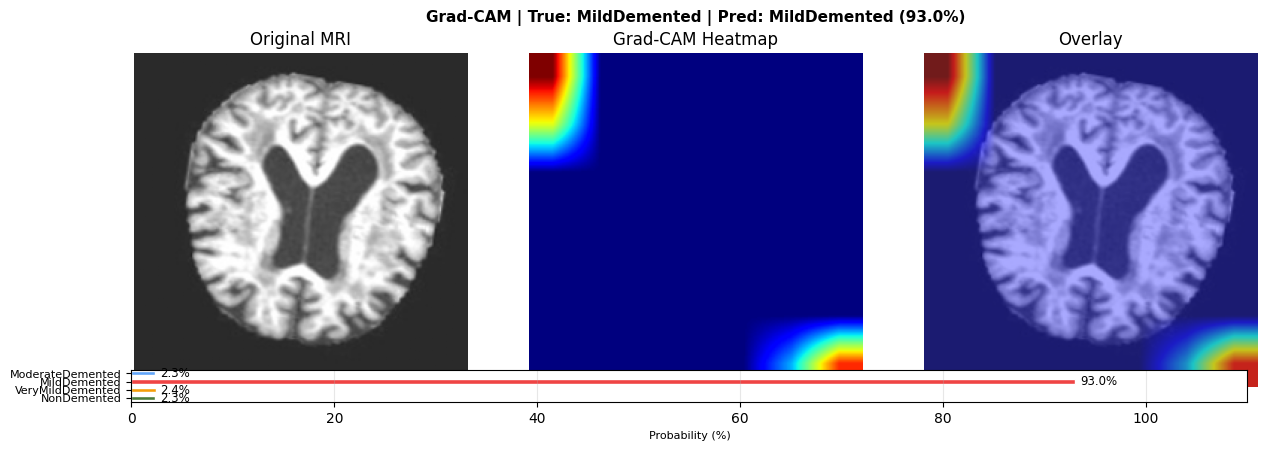

Saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs/gradcam_ModerateDemented_1.png


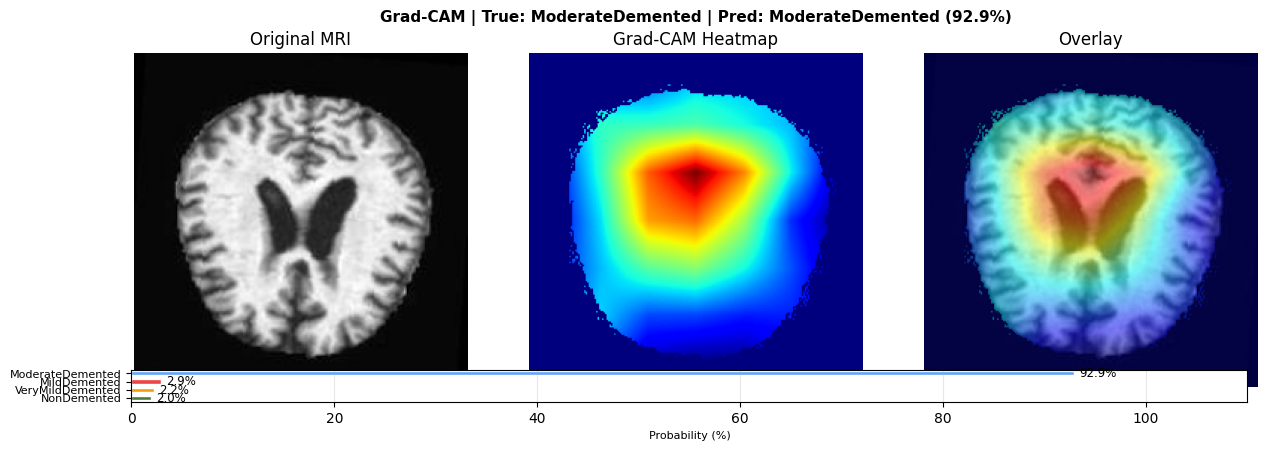

Saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs/gradcam_ModerateDemented_2.png


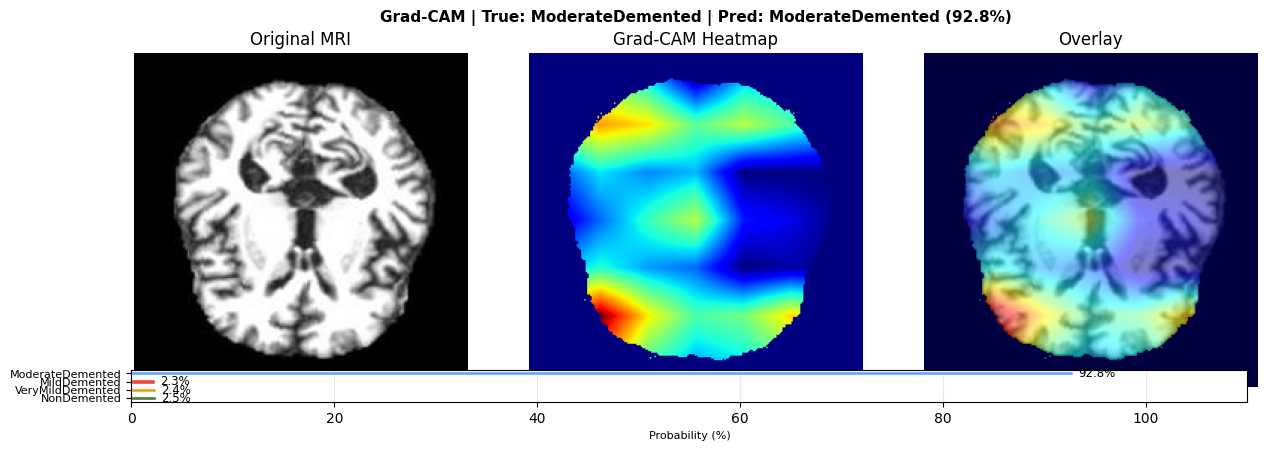

In [ ]:
def get_target_layer(model):
    """Return the last convolutional layer for the architecture."""
    if model.model_name == 'densenet169':
        return model.backbone.features.denseblock4.denselayer32.conv2
    else:
        raise ValueError(f"Unsupported model: {model.model_name}")


def generate_gradcam(model, image_path, true_label, model_name, save_path=None):

    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    #  To resize the image
    orig_img = Image.open(image_path).convert('RGB').resize((cfg.IMG_SIZE, cfg.IMG_SIZE))
    orig_arr = np.array(orig_img).astype(np.float32) / 255.0

    #  Create brain mask
    # Skull-stripped images have true black background
    gray       = np.mean(orig_arr, axis=2)
    brain_mask = (gray > 0.05).astype(np.float32)

    #  Normalise only brain pixels
    img_tensor = torch.tensor(orig_arr).permute(2, 0, 1).float()
    normalise  = transforms.Normalize(mean, std)
    img_tensor = normalise(img_tensor)

    # Zero out background after normalisation so model ignores it
    mask_tensor = torch.tensor(brain_mask).unsqueeze(0)
    img_tensor  = img_tensor * mask_tensor

    input_tensor = img_tensor.unsqueeze(0).to(device)

    #  Grad-CAM
    target_layer = get_target_layer(model)

    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        with torch.no_grad():
            pred_class = model(input_tensor).argmax(dim=1).item()
        targets       = [ClassifierOutputTarget(pred_class)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    #  Mask the heatmap to brain region only
    grayscale_cam = grayscale_cam * brain_mask

    if grayscale_cam.max() > 0:
        grayscale_cam = grayscale_cam / grayscale_cam.max()

    #  To overlay the heatmap on the mri
    heatmap = show_cam_on_image(orig_arr, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        probs = F.softmax(model(input_tensor), dim=1).squeeze().cpu().numpy()

    pred_lbl = cfg.CLASSES[pred_class]
    true_lbl = cfg.CLASSES[true_label]
    conf     = probs[pred_class] * 100

    #  Plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f'Grad-CAM | True: {true_lbl} | Pred: {pred_lbl} ({conf:.1f}%)',
                 fontsize=11, fontweight='bold')

    axes[0].imshow(orig_arr, cmap='gray')
    axes[0].set_title('Original MRI'); axes[0].axis('off')

    axes[1].imshow(grayscale_cam, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Grad-CAM Heatmap'); axes[1].axis('off')

    axes[2].imshow(heatmap)
    axes[2].set_title('Overlay'); axes[2].axis('off')

    # Probability bar
    bar_ax = fig.add_axes([0.03, 0.0, 0.93, 0.08])
    colors = ['#4a7a3a', '#f59e0b', '#ef4444', '#60a5fa']
    bars   = bar_ax.barh(cfg.CLASSES, probs * 100,
                         color=colors[:len(cfg.CLASSES)],
                         edgecolor='white', height=0.5)
    for bar, val in zip(bars, probs * 100):
        bar_ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=8.5)
    bar_ax.set_xlim(0, 110)
    bar_ax.set_xlabel('Probability (%)', fontsize=8)
    bar_ax.tick_params(axis='y', labelsize=8)
    bar_ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

    return grayscale_cam, heatmap


# Generate Grad-CAM for 2 examples per class
print("\nGenerating Grad-CAM examples...")
best_model.eval()
for label_idx, cls in enumerate(cfg.CLASSES):
    cls_path = os.path.join(cfg.DATA_DIR, cls)
    files    = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    samples  = random.sample(files, 2)
    for i, fname in enumerate(samples):
        img_path  = os.path.join(cls_path, fname)
        save_path = f"{cfg.OUTPUT_DIR}/gradcam_{cls}_{i+1}.png"
        generate_gradcam(best_model, img_path, label_idx,
                         cfg.MODEL_NAME, save_path=save_path)

In [ ]:
# Saves the full model artefact that FastAPI will load at startup
def export_for_fastapi(model, model_name):

    export_path = f"{cfg.MODEL_DIR}/{model_name}_fastapi.pt"

    torch.save({
        'model_name':    model_name,
        'num_classes':   cfg.NUM_CLASSES,
        'dropout':       cfg.DROPOUT,
        'class_names':   cfg.CLASSES,
        'img_size':      cfg.IMG_SIZE,
        'state_dict':    model.state_dict(),
        'imagenet_mean': [0.485, 0.456, 0.406],
        'imagenet_std':  [0.229, 0.224, 0.225]
    }, export_path)

    print(f"FastAPI model saved: {export_path}")
    print(f"File size: {os.path.getsize(export_path) / 1e6:.1f} MB")
    return export_path

export_path = export_for_fastapi(best_model, cfg.MODEL_NAME)

FastAPI model saved: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Models/densenet169_fastapi.pt
File size: 54.9 MB


In [ ]:
print("\n" + "=" * 58)
print("  ALL OUTPUTS SAVED TO:", cfg.OUTPUT_DIR)
print("=" * 58)
outputs = [
    "class_distribution.png     — dataset class balance",
    "sample_mri_scans.png       — sample images per class",
    "training_curves.png        — loss / accuracy / LR",
    "confusion_matrix.png       — counts + normalised",
    "roc_curves.png             — AUC per class",
    "pr_curves.png              — precision-recall per class",
    "per_class_metrics.png      — precision/recall/F1 bars",
    "confidence_distribution.png— confidence histograms",
    "gradcam_*.png              — Grad-CAM examples",
    "classification_report.csv  — full metrics table",
    f"{cfg.MODEL_NAME}_best.pt  — best checkpoint",
    f"{cfg.MODEL_NAME}_fastapi.pt— FastAPI export",
    "predict.py                 — FastAPI inference script"
]
for o in outputs:
    print(f"  ✓ {o}")
print("=" * 58)


  ALL OUTPUTS SAVED TO: /content/drive/MyDrive/Colab Notebooks/Alzheimer/Outputs
  ✓ class_distribution.png     — dataset class balance
  ✓ sample_mri_scans.png       — sample images per class
  ✓ training_curves.png        — loss / accuracy / LR
  ✓ confusion_matrix.png       — counts + normalised
  ✓ roc_curves.png             — AUC per class
  ✓ pr_curves.png              — precision-recall per class
  ✓ per_class_metrics.png      — precision/recall/F1 bars
  ✓ confidence_distribution.png— confidence histograms
  ✓ gradcam_*.png              — Grad-CAM examples
  ✓ classification_report.csv  — full metrics table
  ✓ densenet169_best.pt  — best checkpoint
  ✓ densenet169_fastapi.pt— FastAPI export
  ✓ predict.py                 — FastAPI inference script
